In [1]:
import pandas as pd
df = pd.read_csv("battery_stats_cycles_001_750.csv")

print(f"{df.shape[0]}")

print(f"\n{df.head()}")

92717

   cycle_number  voltage_v sample_number  discharge_energy_wh  temperature_c  \
0           1.0   3.669531        01-001             9.198724           10.0   
1           2.0   3.664757        01-001             9.472517           10.0   
2           3.0   3.659098        01-001             9.566450           10.0   
3           4.0   3.655673        01-001             9.611696           10.0   
4           5.0   3.653233        01-001             9.635559           10.0   

   cycle_number_local   source_folder               source_file   source_sheet  
0                 1.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
1                 2.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
2                 3.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
3                 4.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  
4                 5.0  001~050 Cycles  DOE-001-050-10DU 01.xlsx  Statistics_49  


In [2]:
charge_cutoff=['C/5','C/40']
discharge_rate=[0.7,1,2]
temp=[10,25,45,60]
table_list=[]
i=1
for t in temp:
    for d in discharge_rate:
        for c in charge_cutoff:
            table_list.append({'Condition':i, 'Temperature':t, 'Discharge Rate':d, 'Charge Cutoff':c})
            i += 1
cond_guide=pd.DataFrame(table_list)
cond_guide.head(24)


,Condition,Temperature,Discharge Rate,Charge Cutoff
0,1,10,0.7,C/5
1,2,10,0.7,C/40
2,3,10,1.0,C/5
3,4,10,1.0,C/40
4,5,10,2.0,C/5
5,6,10,2.0,C/40
6,7,25,0.7,C/5
7,8,25,0.7,C/40
8,9,25,1.0,C/5
9,10,25,1.0,C/40


In [3]:
# Map df sample prefix (before '-') to cond_guide Condition
# Example: sample_number '01-001' -> condition_id 1

df = df.copy()

# Make this cell rerun-safe by removing prior mapping columns/suffixes
cols_to_remove = [
    c for c in df.columns
    if c in {'condition_id', 'discharge_rate', 'charge_cutoff'}
    or c.startswith('discharge_rate_')
    or c.startswith('charge_cutoff_')
]
if cols_to_remove:
    df = df.drop(columns=cols_to_remove)

# 1) Extract condition id from sample_number prefix
#    Handles values like '01-001', '12-089', etc.
df['condition_id'] = (
    df['sample_number']
    .astype(str)
    .str.extract(r'^(\d+)')[0]
    .astype('Int64')
)

# 2) Prepare lookup table from cond_guide
cond_lookup = cond_guide.rename(columns={
    'Condition': 'condition_id',
    'Discharge Rate': 'discharge_rate',
    'Charge Cutoff': 'charge_cutoff'
})[['condition_id', 'discharge_rate', 'charge_cutoff']].copy()

cond_lookup['condition_id'] = pd.to_numeric(cond_lookup['condition_id'], errors='coerce').astype('Int64')

# 3) Merge to add discharge_rate and charge_cutoff columns
#    validate='m:1' ensures each condition_id maps to at most one row in cond_guide
df = df.merge(cond_lookup, on='condition_id', how='left', validate='m:1')

print(df[['sample_number', 'condition_id', 'discharge_rate', 'charge_cutoff']].head(12))
print('\nMissing mapping rows:', int(df['discharge_rate'].isna().sum()))

df.to_csv("battery_stats_cycles_001_750_mapped.csv", index=False)

   sample_number  condition_id  discharge_rate charge_cutoff
0         01-001             1             0.7           C/5
1         01-001             1             0.7           C/5
2         01-001             1             0.7           C/5
3         01-001             1             0.7           C/5
4         01-001             1             0.7           C/5
5         01-001             1             0.7           C/5
6         01-001             1             0.7           C/5
7         01-001             1             0.7           C/5
8         01-001             1             0.7           C/5
9         01-001             1             0.7           C/5
10        01-001             1             0.7           C/5
11        01-001             1             0.7           C/5

Missing mapping rows: 0


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("battery_stats_cycles_001_750_mapped.csv")
target_col=['discharge_energy_wh']
feature_cols=['cycle_number','sample_number','voltage_v','temperature_c','discharge_rate','charge_cutoff']
print(df.shape)
print(df['discharge_energy_wh'].describe())
missing=df.isnull().sum().sort_values(ascending=False)
print(f'\n{missing}')


(92717, 12)
count    92717.000000
mean         9.593251
std          2.349228
min          0.000000
25%          8.952688
50%         10.352730
75%         11.131760
max         12.860190
Name: discharge_energy_wh, dtype: float64

cycle_number           0
voltage_v              0
sample_number          0
discharge_energy_wh    0
temperature_c          0
cycle_number_local     0
source_folder          0
source_file            0
source_sheet           0
condition_id           0
discharge_rate         0
charge_cutoff          0
dtype: int64


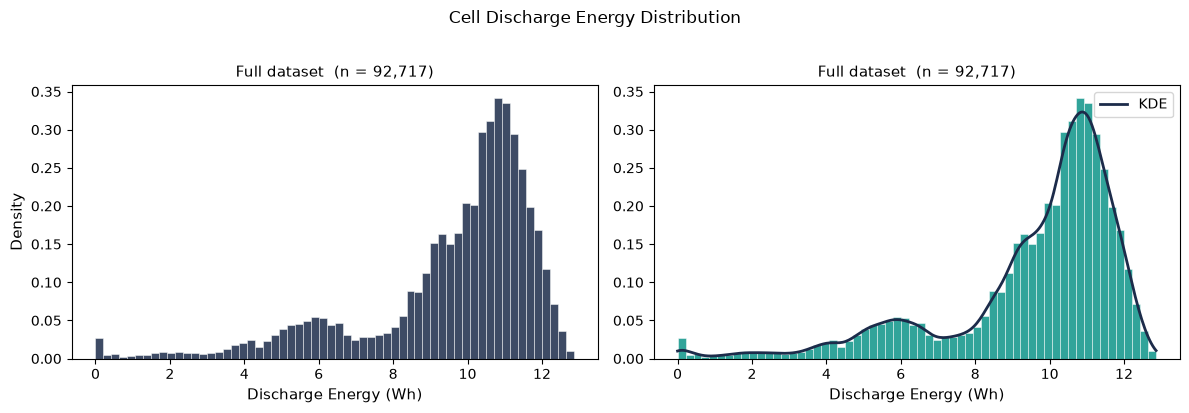

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df['discharge_energy_wh'].dropna(), bins=60, color='#1C2B4A', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Discharge Energy (Wh)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title(f'Full dataset  (n = {df["discharge_energy_wh"].notna().sum():,})', fontsize=11)

axes[1].hist(df['discharge_energy_wh'], bins=60, color='#0D9488', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
from scipy.stats import gaussian_kde
x_kde = np.linspace(df['discharge_energy_wh'].min(), df['discharge_energy_wh'].max(), 300)
axes[1].plot(x_kde, gaussian_kde(df['discharge_energy_wh'].dropna())(x_kde), color='#1C2B4A', lw=2, label='KDE')
axes[1].set_xlabel('Discharge Energy (Wh)', fontsize=11)
axes[1].set_title(f'Full dataset  (n = {df["discharge_energy_wh"].notna().sum():,})', fontsize=11)
axes[1].legend()

plt.suptitle('Cell Discharge Energy Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cell_discharge_energy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from scipy import stats

# Clean data
data = df['discharge_energy_wh'].dropna().values

# Normalize data to [0, 1] for Beta distribution
data_norm = (data - data.min()) / (data.max() - data.min())

# Test multiple distributions
results = []

# 1. Normal distribution (on original data)
params_norm = stats.norm.fit(data)
ks_norm = stats.kstest(data, lambda x: stats.norm.cdf(x, *params_norm))
results.append(('Normal', ks_norm.statistic, ks_norm.pvalue))

# 2. Beta distribution (on normalized data)
params_beta = stats.beta.fit(data_norm)
ks_beta = stats.kstest(data_norm, lambda x: stats.beta.cdf(x, *params_beta))
results.append(('Beta', ks_beta.statistic, ks_beta.pvalue))

print("\nGoodness-of-Fit Test Results:")
for dist_name, ks_stat, p_value in results:
    print(f"{dist_name}: KS Statistic = {ks_stat:.4f}, p-value = {p_value:.4f}")
    



c:\Users\RXT0TKQ\AppData\Local\miniconda3\miniconda\envs\matds\Lib\site-packages\scipy\stats\_continuous_distns.py:806: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)



Goodness-of-Fit Test Results:
Normal: KS Statistic = 0.1530, p-value = 0.0000
Beta: KS Statistic = 0.1096, p-value = 0.0000


In [7]:
from scipy import stats
import numpy as np
import pandas as pd

data = df['discharge_energy_wh'].dropna().values
n = len(data)
data_norm = (data - data.min()) / (data.max() - data.min())

# Add small epsilon to avoid exact 0 and 1 boundaries for Beta distribution
eps = 1e-6
data_norm_safe = np.clip(data_norm, eps, 1 - eps)

# Fit distributions and compute BIC
results = []

# 1. Normal distribution
params_norm = stats.norm.fit(data)
loglik_norm = np.sum(stats.norm.logpdf(data, *params_norm))
k_norm = 2  # mu, sigma
bic_norm = k_norm * np.log(n) - 2 * loglik_norm
results.append({
    'Distribution': 'Normal',
    'Parameters': f'μ={params_norm[0]:.3f}, σ={params_norm[1]:.3f}',
    'Log-Likelihood': loglik_norm,
    'k (# params)': k_norm,
    'BIC': bic_norm
})

# 2. Beta distribution (fitted on normalized data, with safe boundaries)
params_beta = stats.beta.fit(data_norm_safe)
loglik_beta = np.sum(stats.beta.logpdf(data_norm_safe, params_beta[0], params_beta[1]))
k_beta = 2  # alpha, beta
bic_beta = k_beta * np.log(n) - 2 * loglik_beta
results.append({
    'Distribution': 'Beta',
    'Parameters': f'α={params_beta[0]:.3f}, β={params_beta[1]:.3f}',
    'Log-Likelihood': loglik_beta,
    'k (# params)': k_beta,
    'BIC': bic_beta
})

# 3. Gamma distribution
params_gamma = stats.gamma.fit(data)
loglik_gamma = np.sum(stats.gamma.logpdf(data, params_gamma[0], loc=params_gamma[1], scale=params_gamma[2]))
k_gamma = 2  # shape, scale
bic_gamma = k_gamma * np.log(n) - 2 * loglik_gamma
results.append({
    'Distribution': 'Gamma',
    'Parameters': f'shape={params_gamma[0]:.3f}, scale={params_gamma[2]:.3f}',
    'Log-Likelihood': loglik_gamma,
    'k (# params)': k_gamma,
    'BIC': bic_gamma
})

# 4. Skew-Normal distribution
params_skewnorm = stats.skewnorm.fit(data)
loglik_skewnorm = np.sum(stats.skewnorm.logpdf(data, params_skewnorm[0]))
k_skewnorm = 3  # skewness, mu, sigma
bic_skewnorm = k_skewnorm * np.log(n) - 2 * loglik_skewnorm
results.append({
    'Distribution': 'Skew-Normal',
    'Parameters': f'skew={params_skewnorm[0]:.3f}, μ={params_skewnorm[1]:.3f}, σ={params_skewnorm[2]:.3f}',
    'Log-Likelihood': loglik_skewnorm,
    'k (# params)': k_skewnorm,
    'BIC': bic_skewnorm
})

# Create DataFrame and sort by BIC (lower is better)
bic_df = pd.DataFrame(results).sort_values('BIC')

print("\n" + "="*90)
print("BIC Model Comparison (Lower BIC = Better Fit)")
print("="*90)
print(bic_df.to_string(index=False))
print("\n" + "="*90)
print(f"Best model: {bic_df.iloc[0]['Distribution']} (BIC = {bic_df.iloc[0]['BIC']:.2f})")
print("="*90)

# Calculate BIC differences relative to best model
bic_df['ΔBIC'] = bic_df['BIC'] - bic_df['BIC'].min()
print("\nBIC Differences from Best Model:")
print(bic_df[['Distribution', 'BIC', 'ΔBIC']].to_string(index=False))
print("\nInterpretation:")
print("- ΔBIC < 2: Essentially equivalent support")
print("- ΔBIC 2-7: Considerably less support")
print("- ΔBIC > 10: Essentially no support")



BIC Model Comparison (Lower BIC = Better Fit)
Distribution                      Parameters  Log-Likelihood  k (# params)           BIC
        Beta                α=5.644, β=1.678    2.743886e+04             2 -5.485484e+04
      Normal                μ=9.593, σ=2.349   -2.107476e+05             2  4.215180e+05
       Gamma      shape=237.683, scale=0.163   -2.141356e+05             2  4.282940e+05
 Skew-Normal skew=-11.029, μ=12.192, σ=3.503   -5.551144e+08             3  1.110229e+09

Best model: Beta (BIC = -54854.84)

BIC Differences from Best Model:
Distribution           BIC         ΔBIC
        Beta -5.485484e+04 0.000000e+00
      Normal  4.215180e+05 4.763729e+05
       Gamma  4.282940e+05 4.831489e+05
 Skew-Normal  1.110229e+09 1.110284e+09

Interpretation:
- ΔBIC < 2: Essentially equivalent support
- ΔBIC 2-7: Considerably less support
- ΔBIC > 10: Essentially no support


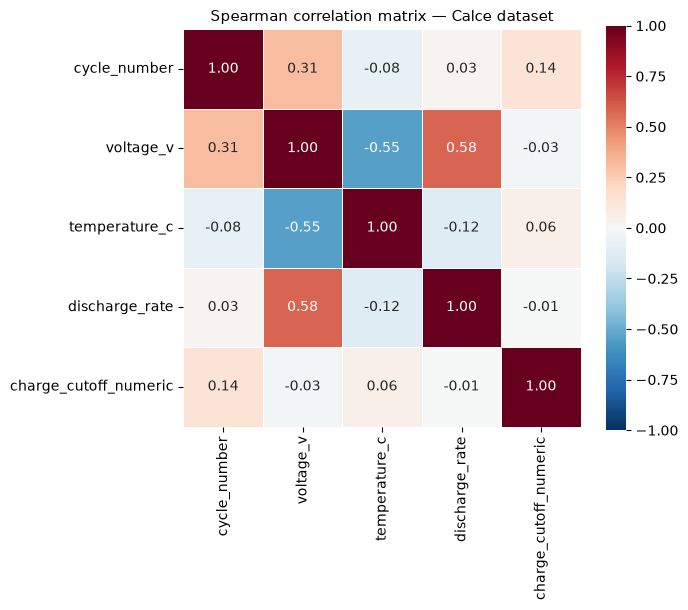

Spearman correlation matrix:
                       cycle_number  voltage_v  temperature_c  discharge_rate  \
cycle_number                  1.000      0.308         -0.085           0.030   
voltage_v                     0.308      1.000         -0.550           0.582   
temperature_c                -0.085     -0.550          1.000          -0.121   
discharge_rate                0.030      0.582         -0.121           1.000   
charge_cutoff_numeric         0.135     -0.028          0.061          -0.006   

                       charge_cutoff_numeric  
cycle_number                           0.135  
voltage_v                             -0.028  
temperature_c                          0.061  
discharge_rate                        -0.006  
charge_cutoff_numeric                  1.000  


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

def charge_cutoff_to_numeric(val):
    if pd.isna(val):
        return None
    denominator = int(val.split('/')[1])
    return 1.0 / denominator

df['charge_cutoff_numeric'] = df['charge_cutoff'].apply(charge_cutoff_to_numeric)
feature_cols=['cycle_number','sample_number','voltage_v','temperature_c','discharge_rate','charge_cutoff_numeric']
# Select only numeric features (exclude categorical columns: sample_number, charge_cutoff)
numeric_features = [col for col in feature_cols if col not in ['sample_number']]
corr = df[numeric_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Spearman correlation matrix — Calce dataset', fontsize=11)
plt.tight_layout()
plt.savefig('Spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spearman correlation matrix:")
print(corr.round(3))

In [9]:
Q1  = df['discharge_energy_wh'].quantile(0.25)
Q3  = df['discharge_energy_wh'].quantile(0.75)
IQR_val = Q3 - Q1
lo  = Q1 - 1.5 * IQR_val
hi  = Q3 + 1.5 * IQR_val

outliers = df[((df['discharge_energy_wh'] < lo) | (df['discharge_energy_wh'] > hi))]

print(f"Q1 = {Q1:.3f} Wh   Q3 = {Q3:.3f} Wh   IQR = {IQR_val:.3f} Wh")
print(f"IQR fences: lower = {lo:.3f} Wh   upper = {hi:.3f} Wh")
print(f"Flagged as outliers: {len(outliers):,}  ({100*len(outliers)/len(df):.1f}% of dataset)")
print()
print("10 largest energy outliers:")
print(outliers.nsmallest(10, 'discharge_energy_wh')[['sample_number','discharge_energy_wh','cycle_number']].to_string(index=False))

Q1 = 8.953 Wh   Q3 = 11.132 Wh   IQR = 2.179 Wh
IQR fences: lower = 5.684 Wh   upper = 14.400 Wh
Flagged as outliers: 8,272  (8.9% of dataset)

10 largest energy outliers:
sample_number  discharge_energy_wh  cycle_number
       01-006                  0.0          27.0
       01-006                  0.0          33.0
       02-009                  0.0         401.0
       03-017                  0.0         665.0
       04-027                  0.0          74.0
       05-033                  0.0         166.0
       05-033                  0.0         213.0
       05-033                  0.0         214.0
       05-033                  0.0         216.0
       05-033                  0.0         236.0


In [10]:
# should I exclude outliers with 0 discharge energy? yes i think so cause the file shows subsequent cycles returning to a normal discharge energy after the 0 value. This suggests that the 0 value is likely an anomaly or error in the data collection process, rather than a true representation of the battery's performance. Excluding these outliers will provide a more accurate analysis of the battery's discharge energy distribution and improve the reliability of any statistical models built on this data.

In [11]:
df = df[df['discharge_energy_wh'] > 0.5]
df.describe()

,cycle_number,voltage_v,discharge_energy_wh,temperature_c,cycle_number_local,condition_id,discharge_rate,charge_cutoff_numeric
count,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000,91999.000000
mean,284.199285,3.541984,9.666919,32.423287,25.289949,11.370754,1.192198,0.124321
std,180.921741,0.185716,2.204754,18.267374,14.432654,6.401746,0.539129,0.086698
min,1.000000,2.999993,0.502525,10.000000,1.000000,1.000000,0.700000,0.025000
25%,129.000000,3.374505,8.993271,10.000000,13.000000,6.000000,0.700000,0.025000
50%,266.000000,3.618751,10.363900,25.000000,25.000000,12.000000,1.000000,0.200000
75%,426.000000,3.676163,11.138110,45.000000,38.000000,17.000000,2.000000,0.200000
max,750.000000,4.293325,12.860190,60.000000,50.000000,24.000000,2.000000,0.200000


In [12]:
Q1  = df['discharge_energy_wh'].quantile(0.25)
Q3  = df['discharge_energy_wh'].quantile(0.75)
IQR_val = Q3 - Q1
lo  = Q1 - 1.5 * IQR_val
hi  = Q3 + 1.5 * IQR_val

outliers = df[((df['discharge_energy_wh'] < lo) | (df['discharge_energy_wh'] > hi))]

print(f"Q1 = {Q1:.3f} Wh   Q3 = {Q3:.3f} Wh   IQR = {IQR_val:.3f} Wh")
print(f"IQR fences: lower = {lo:.3f} Wh   upper = {hi:.3f} Wh")
print(f"Flagged as outliers: {len(outliers):,}  ({100*len(outliers)/len(df):.1f}% of dataset)")
print()
print("10 largest energy outliers:")
print(outliers.nsmallest(10, 'discharge_energy_wh')[['sample_number','discharge_energy_wh','cycle_number']].to_string(index=False))

Q1 = 8.993 Wh   Q3 = 11.138 Wh   IQR = 2.145 Wh
IQR fences: lower = 5.776 Wh   upper = 14.355 Wh
Flagged as outliers: 7,993  (8.7% of dataset)

10 largest energy outliers:
sample_number  discharge_energy_wh  cycle_number
       14-112             0.502525         432.0
       14-112             0.503842         425.0
       14-112             0.504604         424.0
       14-112             0.506823         423.0
       14-112             0.507192         431.0
       14-112             0.507979         422.0
       14-112             0.510167         421.0
       14-112             0.511501         419.0
       14-112             0.512814         420.0
       14-112             0.515710         418.0


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GroupKFold, cross_val_score,
    RandomizedSearchCV, learning_curve, train_test_split)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
df_clean=df.copy()

# Convert charge_cutoff to numeric (preserve physical meaning)
# 'C/5' → 1/5 = 0.20,  'C/40' → 1/40 = 0.025
def charge_cutoff_to_numeric(val):
    if pd.isna(val):
        return None
    denominator = int(val.split('/')[1])
    return 1.0 / denominator

df_clean['charge_cutoff_numeric'] = df_clean['charge_cutoff'].apply(charge_cutoff_to_numeric)

# discharge_rate is already numeric (0.7C, 1C, 2C in C-rate form)
# Model features: exclude 'sample_number' and 'charge_cutoff', use 'charge_cutoff_numeric'
model_features = ['cycle_number', 'voltage_v', 'temperature_c', 'discharge_rate', 'charge_cutoff_numeric']

X_all = df_clean[model_features].values
y_all = df_clean['discharge_energy_wh'].values

groups = df_clean['sample_number'].values
gkf    = GroupKFold(n_splits=5)

folds = list(gkf.split(X_all, y_all, groups))
train_idx, test_idx = folds[0]

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
groups_train    = groups[train_idx]

print(f"Fold 0 - Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train mean discharge_energy_wh: {y_train.mean():.3f} Wh")
print(f"Test  mean discharge_energy_wh: {y_test.mean():.3f} Wh")

# Confirm no composition overlap between train and test
train_formulas = set(df_clean.iloc[train_idx]['sample_number'])
test_formulas  = set(df_clean.iloc[test_idx]['sample_number'])
overlap = train_formulas & test_formulas
print(f"\nComposition overlap between train and test: {len(overlap)} formulas")
print("(Should be 0 - that is the point of GroupKFold)")

Fold 0 - Train: 73,599  |  Test: 18,400
Train mean discharge_energy_wh: 9.686 Wh
Test  mean discharge_energy_wh: 9.590 Wh

Composition overlap between train and test: 0 formulas
(Should be 0 - that is the point of GroupKFold)


In [14]:
#doing cross validation with the random forest model across all folds and also with GroupKFold to see if there is any inflation in the R2 score due to the random split. Also calculating MAE and RMSE for the GroupKFold cross validation.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))
])

r2_random = cross_val_score(pipe, X_all, y_all, cv=5, scoring="r2")

r2_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="r2")

mae_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="neg_mean_absolute_error")

rmse_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="neg_root_mean_squared_error")

print("=" * 50)
print(f"Random 5-fold CV R2:  {r2_random.mean():.3f} ± {r2_random.std():.3f}")
print(f"GroupKFold R2:        {r2_group.mean():.3f}  ± {r2_group.std():.3f}")
print(f"Inflation from random split: {r2_random.mean() - r2_group.mean():.3f}")

print(f"GroupKFold MAE:       {-mae_group.mean():.3f} ± {-mae_group.std():.3f}")
print(f"GroupKFold RMSE:      {-rmse_group.mean():.3f} ± {-rmse_group.std():.3f}")
print("=" * 50)




Random 5-fold CV R2:  -0.274 ± 1.743
GroupKFold R2:        0.993  ± 0.003
Inflation from random split: -1.267
GroupKFold MAE:       0.068 ± -0.005
GroupKFold RMSE:      0.185 ± -0.034


In [15]:
# Cell B3
# LECTURE DEMO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test

print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"X_test_scaled  mean: {X_test_scaled.mean():.4f}  (not guaranteed ~0)")

X_train_scaled mean: 0.0000  std: 1.0000
X_test_scaled  mean: 0.0046  (not guaranteed ~0)


In [16]:
#testing the random forest model on one fold as a baseline for comparison with the tuned model.
rf_default = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_default.fit(X_train_scaled, y_train)
y_pred_default = rf_default.predict(X_test_scaled)

r2_def  = r2_score(y_test, y_pred_default)
mae_def = mean_absolute_error(y_test, y_pred_default)
rmse_def= np.sqrt(mean_squared_error(y_test, y_pred_default))

print("Default RF:")
print(f"  R2:   {r2_def:.3f}")
print(f"  MAE:  {mae_def:.3f} eV")
print(f"  RMSE: {rmse_def:.3f} eV")

Default RF:
  R2:   0.991
  MAE:  0.074 eV
  RMSE: 0.195 eV


RidgeCV best alpha: 10000.0000
Ridge  R²:   0.721
Ridge  MAE:  0.861 Wh


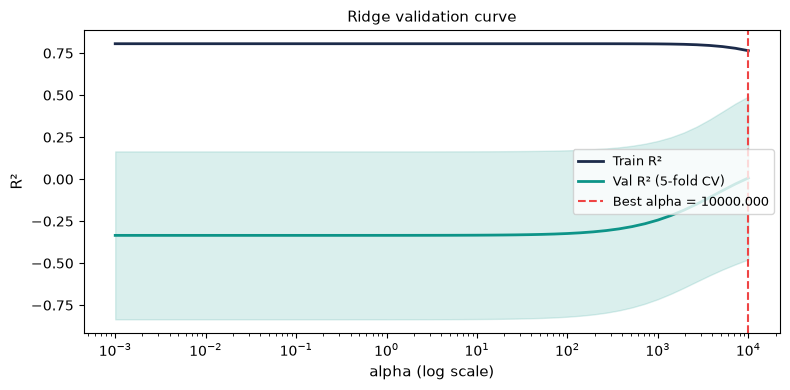

In [17]:
#validation curve shows that ridge regression performs poorly and doesn't generalize well as evidenced by the CV R² scores being lower than the training R² scores. This suggests that ridge regression is not a good fit for this dataset and that a more complex model, such as random forest, may be more appropriate.
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import validation_curve

alphas = np.logspace(-3, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")
print(f"Ridge  R²:   {r2_ridge:.3f}")
print(f"Ridge  MAE:  {mae_ridge:.3f} Wh")

# Validation curve
from sklearn.linear_model import Ridge as RidgePlain
tr_scores, val_scores = validation_curve(
    RidgePlain(), X_train_scaled, y_train,
    param_name='alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, tr_scores.mean(1),  color='#1C2B4A', lw=2, label='Train R²')
ax.semilogx(alphas, val_scores.mean(1), color='#0D9488', lw=2, label='Val R² (5-fold CV)')
ax.fill_between(alphas, val_scores.mean(1)-val_scores.std(1),
                         val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#0D9488')
ax.axvline(ridge_cv.alpha_, color='#EF4444', lw=1.5, ls='--',
           label=f'Best alpha = {ridge_cv.alpha_:.3f}')
ax.set_xlabel('alpha (log scale)', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Ridge validation curve', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('C2_ridge_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#tuning the model using one fold.
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "rf__n_estimators":     [100, 200, 300, 500],
    "rf__max_depth":        [None, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features":     ["sqrt", "log2", 0.3],
}

rscv = RandomizedSearchCV(
    pipe, param_dist, n_iter=15,
    cv=GroupKFold(n_splits=5),
    scoring="r2", n_jobs=-1, random_state=42, verbose=0
)
rscv.fit(X_train, y_train, groups=groups_train)

best_model    = rscv
best_params   = rscv.best_params_
best_cv_score = rscv.best_score_
print("Method: RandomizedSearchCV (15 random trials)")

Method: RandomizedSearchCV (15 random trials)


In [19]:
#this is just the tuned model executed on one fold.
y_pred_tuned = best_model.predict(X_test)
r2_tuned   = r2_score(y_test, y_pred_tuned)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

comparison = pd.DataFrame({
    'Model':  ['Default RF', 'Tuned RF (RandomizedSearch)'],
    'R2':     [round(r2_def,3),   round(r2_tuned,3)],
    'MAE':    [round(mae_def,3),  round(mae_tuned,3)],
    'RMSE':   [round(rmse_def,3), round(rmse_tuned,3)],
})
print(comparison.to_string(index=False))


                      Model    R2   MAE  RMSE
                 Default RF 0.991 0.074 0.195
Tuned RF (RandomizedSearch) 0.990 0.074 0.212


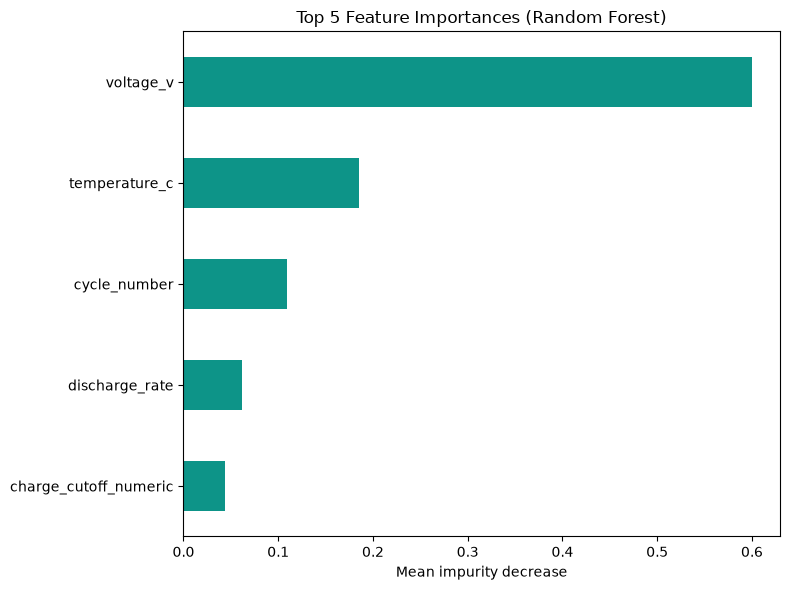

Top 5 features:
voltage_v                0.5996
temperature_c            0.1856
cycle_number             0.1093
discharge_rate           0.0620
charge_cutoff_numeric    0.0435
dtype: float64


In [20]:
best_rf = rscv.best_estimator_.named_steps['rf']
importances = pd.Series(best_rf.feature_importances_, index=model_features)
top = importances.nlargest(5)

fig, ax = plt.subplots(figsize=(8, 6))
top.sort_values().plot(kind='barh', color='#0D9488', ax=ax)
ax.set_xlabel('Mean impurity decrease')
ax.set_title('Top 5 Feature Importances (Random Forest)', fontsize=12)
plt.tight_layout()
plt.savefig('D1_feature_importance.png', dpi=150)
plt.show()

print("Top 5 features:")
print(top.head(5).round(4))

In [21]:
#random forest model with GroupKFold cross validation to evaluate the model performance across all folds and collect predictions for further analysis.
all_y_test = []
all_y_pred = []

for train_idx, test_idx in GroupKFold(n_splits=5).split(X_all, y_all, groups):
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_all[train_idx])
    X_test_fold = scaler.transform(X_all[test_idx])

    model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    model.fit(X_train_fold, y_all[train_idx])
    preds = model.predict(X_test_fold)

    all_y_test.append(y_all[test_idx])
    all_y_pred.append(preds)

all_y_test = np.concatenate(all_y_test)
all_y_pred = np.concatenate(all_y_pred)

print(len(all_y_test), len(all_y_pred))


91999 91999


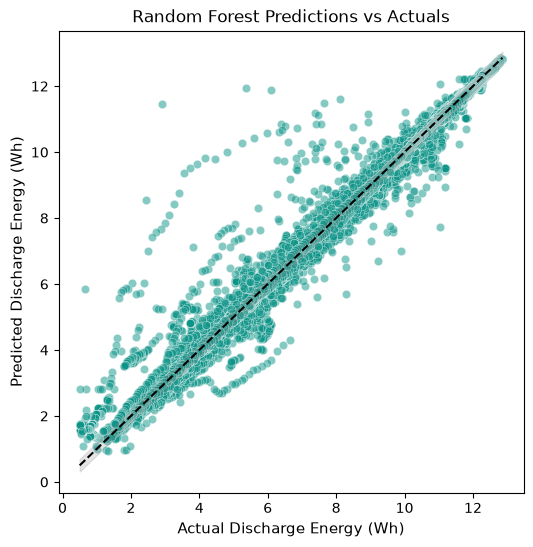

Residual standard deviation: 0.188 Wh
Mean absolute error: 0.068 Wh


In [22]:
residuals = all_y_pred - all_y_test
residual_std = np.std(residuals)
mae = np.mean(np.abs(residuals))
fig,ax = plt.subplots(figsize=(6, 6))

ax.scatter(all_y_test, all_y_pred, alpha=0.5, color='#0D9488', edgecolor='white', linewidth=0.4)
lims = [
    min(all_y_test.min(), all_y_pred.min()),
    max(all_y_test.max(), all_y_pred.max())
]
ax.fill_between(lims, lims - residual_std, lims + residual_std,
                alpha=0.2, color='grey', label=f'±MAE (MAE={mae:.3f} Wh)')

ax.set_xlabel('Actual Discharge Energy (Wh)', fontsize=11)
ax.set_ylabel('Predicted Discharge Energy (Wh)', fontsize=11)
ax.set_title('Random Forest Predictions vs Actuals', fontsize=12)
plt.plot(lims, lims, 'k--')
plt.show()
print(f"Residual standard deviation: {residual_std:.3f} Wh")
print(f"Mean absolute error: {mae:.3f} Wh")

In [23]:
residuals = all_y_pred - all_y_test
mae = np.mean(np.abs(residuals))

# Calculate percentage within ±MAE
pct_within_mae = 100 * np.mean(np.abs(residuals) <= mae)
print(f"MAE: {mae:.3f} Wh")
print(f"Percentage of residuals within ±MAE: {pct_within_mae:.1f}%")

# Also check ±1 std for reference
residual_std = np.std(residuals)
pct_within_1std = 100 * np.mean(np.abs(residuals) <= residual_std)
print(f"Residual Std: {residual_std:.3f} Wh")
print(f"Percentage of residuals within ±1 std: {pct_within_1std:.1f}%")

MAE: 0.068 Wh
Percentage of residuals within ±MAE: 74.8%
Residual Std: 0.188 Wh
Percentage of residuals within ±1 std: 94.8%


In [24]:
#use the model tuned on one fold and evaluate it across all folds using GroupKFold cross validation. This will give a more robust estimate of the model's performance and help to avoid overfitting to a single fold.
from sklearn.base import clone

outer_gkf = GroupKFold(n_splits=5)

tuned_rows = []

for fold_num, (train_idx, test_idx) in enumerate(
    outer_gkf.split(X_all, y_all, groups), start=1
):
    X_train_outer, X_test_outer = X_all[train_idx], X_all[test_idx]
    y_train_outer, y_test_outer = y_all[train_idx], y_all[test_idx]
    groups_train_outer = groups[train_idx]

    # Clone the best estimator and fit on this fold's training data
    fold_model = clone(best_model.best_estimator_)
    fold_model.fit(X_train_outer, y_train_outer)
    y_pred_tuned_outer = fold_model.predict(X_test_outer)

    tuned_rows.append({
        "Fold": fold_num,
        "R2": r2_score(y_test_outer, y_pred_tuned_outer),
        "MAE": mean_absolute_error(y_test_outer, y_pred_tuned_outer),
        "RMSE": np.sqrt(mean_squared_error(y_test_outer, y_pred_tuned_outer))
    })


tuned_df = pd.DataFrame(tuned_rows)
tuned_mean_r2,tuned_std = tuned_df['R2'].aggregate(['mean', 'std'])
print(tuned_df)
print(f"\nTuned RF (RandomizedSearchCV) - GroupKFold 5-fold CV: R2 = {tuned_mean_r2:.3f} ± {tuned_std:.3f}")

   Fold        R2       MAE      RMSE
0     1  0.989921  0.074214  0.211757
1     2  0.994771  0.067717  0.162662
2     3  0.980153  0.073002  0.299764
3     4  0.987878  0.073063  0.250195
4     5  0.995023  0.060844  0.156965

Tuned RF (RandomizedSearchCV) - GroupKFold 5-fold CV: R2 = 0.990 ± 0.006


In [25]:
#PCA and UMAP dimensionality reduction on the dataset to visualize the data in 2D space and see if there are any patterns or clusters based on the features.
#done on one fold 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap


pca10 = PCA(n_components=5, random_state=42)
X_train_pca = pca10.fit_transform(X_train_scaled)

print(f"PCA-10 cumulative variance: {pca10.explained_variance_ratio_.sum():.1%}")

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_train = reducer.fit_transform(X_train_pca)

np.save('umap_train.npy', embedding_train)
print(f"Training embedding shape: {embedding_train.shape}")


PCA-10 cumulative variance: 100.0%


c:\Users\RXT0TKQ\AppData\Local\miniconda3\miniconda\envs\matds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training embedding shape: (73599, 2)


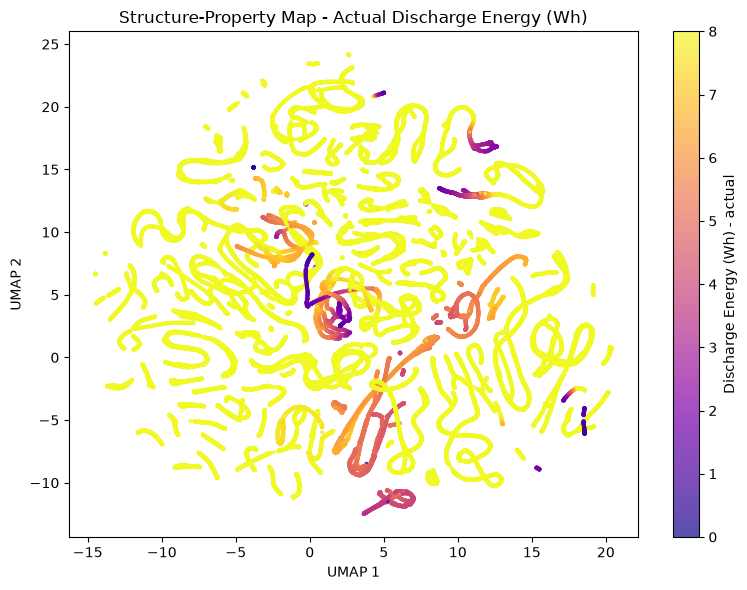

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding_train[:,0], embedding_train[:,1],
                c=y_train, cmap='plasma', vmin=0, vmax=8, s=4, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Discharge Energy (Wh) - actual')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('Structure-Property Map - Actual Discharge Energy (Wh)', fontsize=12)
plt.tight_layout()
plt.savefig('DE_umap_actual.png', dpi=150)
plt.show()

In [27]:
# Feature ablation: Test model performance WITHOUT voltage
# to determine if voltage is doing all the prediction work

model_features_no_voltage = ['cycle_number', 'temperature_c', 'discharge_rate', 'charge_cutoff_numeric']

X_all_no_v = df_clean[model_features_no_voltage].values
y_all_same = df_clean['discharge_energy_wh'].values

r2_no_voltage = cross_val_score(pipe, X_all_no_v, y_all_same,
                                cv=GroupKFold(5), groups=groups, scoring="r2")

mae_no_voltage = cross_val_score(pipe, X_all_no_v, y_all_same,
                                 cv=GroupKFold(5), groups=groups, scoring="neg_mean_absolute_error")

print("=" * 60)
print("Feature Ablation Study: Model Performance WITHOUT Voltage")
print("=" * 60)
print(f"With voltage    - R²: {r2_group.mean():.3f} ± {r2_group.std():.3f}  |  MAE: {-mae_group.mean():.3f} ± {-mae_group.std():.3f}")
print(f"Without voltage - R²: {r2_no_voltage.mean():.3f} ± {r2_no_voltage.std():.3f}  |  MAE: {-mae_no_voltage.mean():.3f} ± {-mae_no_voltage.std():.3f}")
print(f"\nR² Drop: {r2_group.mean() - r2_no_voltage.mean():.3f}")
print("=" * 60)

Feature Ablation Study: Model Performance WITHOUT Voltage
With voltage    - R²: 0.993 ± 0.003  |  MAE: 0.068 ± -0.005
Without voltage - R²: 0.923 ± 0.042  |  MAE: 0.192 ± -0.015

R² Drop: 0.069
